In [51]:
import numpy as np
import pandas as pd
df = pd.read_csv("preprocessed_eastwest_airlines.csv")
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,16420,0,1,1,1,0,0,0,0,6942,0
...,...,...,...,...,...,...,...,...,...,...,...
2870,18476,0,1,1,1,8525,4,200,1,1403,1
2871,64385,0,1,1,1,981,5,0,0,1395,1
2872,73597,0,3,1,1,25447,8,0,0,1402,1
2873,54899,0,1,1,1,500,1,500,1,1401,0


In [52]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,16420,0,1,1,1,0,0,0,0,6942,0


In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [54]:
df = df.fillna(df.median(numeric_only=True))
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,16420,0,1,1,1,0,0,0,0,6942,0
...,...,...,...,...,...,...,...,...,...,...,...
2870,18476,0,1,1,1,8525,4,200,1,1403,1
2871,64385,0,1,1,1,981,5,0,0,1395,1
2872,73597,0,3,1,1,25447,8,0,0,1402,1
2873,54899,0,1,1,1,500,1,500,1,1401,0


In [57]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2875 entries, 0 to 2874
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            2875 non-null   int64
 1   Qual_miles         2875 non-null   int64
 2   cc1_miles          2875 non-null   int64
 3   cc2_miles          2875 non-null   int64
 4   cc3_miles          2875 non-null   int64
 5   Bonus_miles        2875 non-null   int64
 6   Bonus_trans        2875 non-null   int64
 7   Flight_miles_12mo  2875 non-null   int64
 8   Flight_trans_12    2875 non-null   int64
 9   Days_since_enroll  2875 non-null   int64
 10  Award?             2875 non-null   int64
dtypes: int64(11)
memory usage: 247.2 KB


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2875.000000,2875.0,2875.000000,2875.0,2875.0,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000
mean,46840.297739,0.0,1.829913,1.0,1.0,10872.930435,9.385739,57.085217,0.198609,3926.959652,0.279652
std,42611.722286,0.0,1.154373,0.0,0.0,13664.119401,7.753492,150.711569,0.484841,2044.017792,0.448906
min,50.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,15275.000000,0.0,1.000000,1.0,1.0,500.000000,2.000000,0.000000,0.000000,2154.500000,0.000000
50%,33327.000000,0.0,1.000000,1.0,1.0,4500.000000,9.000000,0.000000,0.000000,3805.000000,0.000000
75%,65980.500000,0.0,3.000000,1.0,1.0,17089.000000,15.000000,0.000000,0.000000,5566.000000,1.000000
max,202636.000000,0.0,5.000000,1.0,1.0,57382.000000,38.000000,767.000000,2.000000,8296.000000,1.000000


In [60]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,16420,0,1,1,1,0,0,0,0,6942,0
...,...,...,...,...,...,...,...,...,...,...,...
2866,11310,0,1,1,1,5021,2,0,0,1409,0
2867,39142,0,3,1,1,14981,28,0,0,1408,0
2868,11181,0,1,1,1,929,12,0,0,1407,0
2869,3974,0,1,1,1,365,3,0,0,1397,0


In [62]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.select_dtypes(include=[np.number]))
df_scaled = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[np.number]).columns)
df_scaled 

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.141554,0.0,-0.477118,0.0,0.0,-0.664661,-0.824536,0.0,0.0,1.655278,0.0
1,-0.475535,0.0,-0.477118,0.0,0.0,-0.658450,-0.680951,0.0,0.0,1.639811,0.0
2,0.354258,0.0,-0.477118,0.0,0.0,-0.066378,-0.393782,0.0,0.0,1.671712,0.0
3,-0.643220,0.0,-0.477118,0.0,0.0,-0.615271,-0.824536,0.0,0.0,1.632078,0.0
4,-0.581520,0.0,-0.477118,0.0,0.0,-0.691023,-0.968121,0.0,0.0,1.627245,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1564,-0.773299,0.0,-0.477118,0.0,0.0,0.069671,-0.680951,0.0,0.0,-1.047077,0.0
1565,0.271241,0.0,2.458561,0.0,0.0,1.578635,3.052248,0.0,0.0,-1.047560,0.0
1566,-0.778141,0.0,-0.477118,0.0,0.0,-0.550277,0.754894,0.0,0.0,-1.048043,0.0
1567,-1.048621,0.0,-0.477118,0.0,0.0,-0.635724,-0.537367,0.0,0.0,-1.052877,0.0


C:\Users\amarm\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


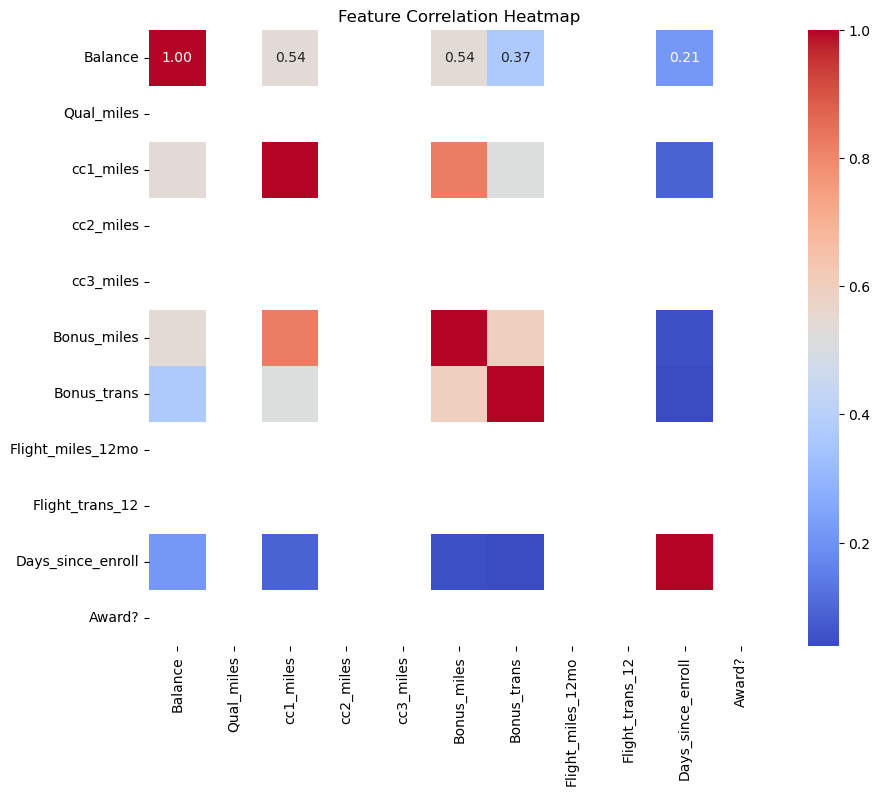

In [63]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\amarm\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\amarm\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\amarm\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\amarm\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

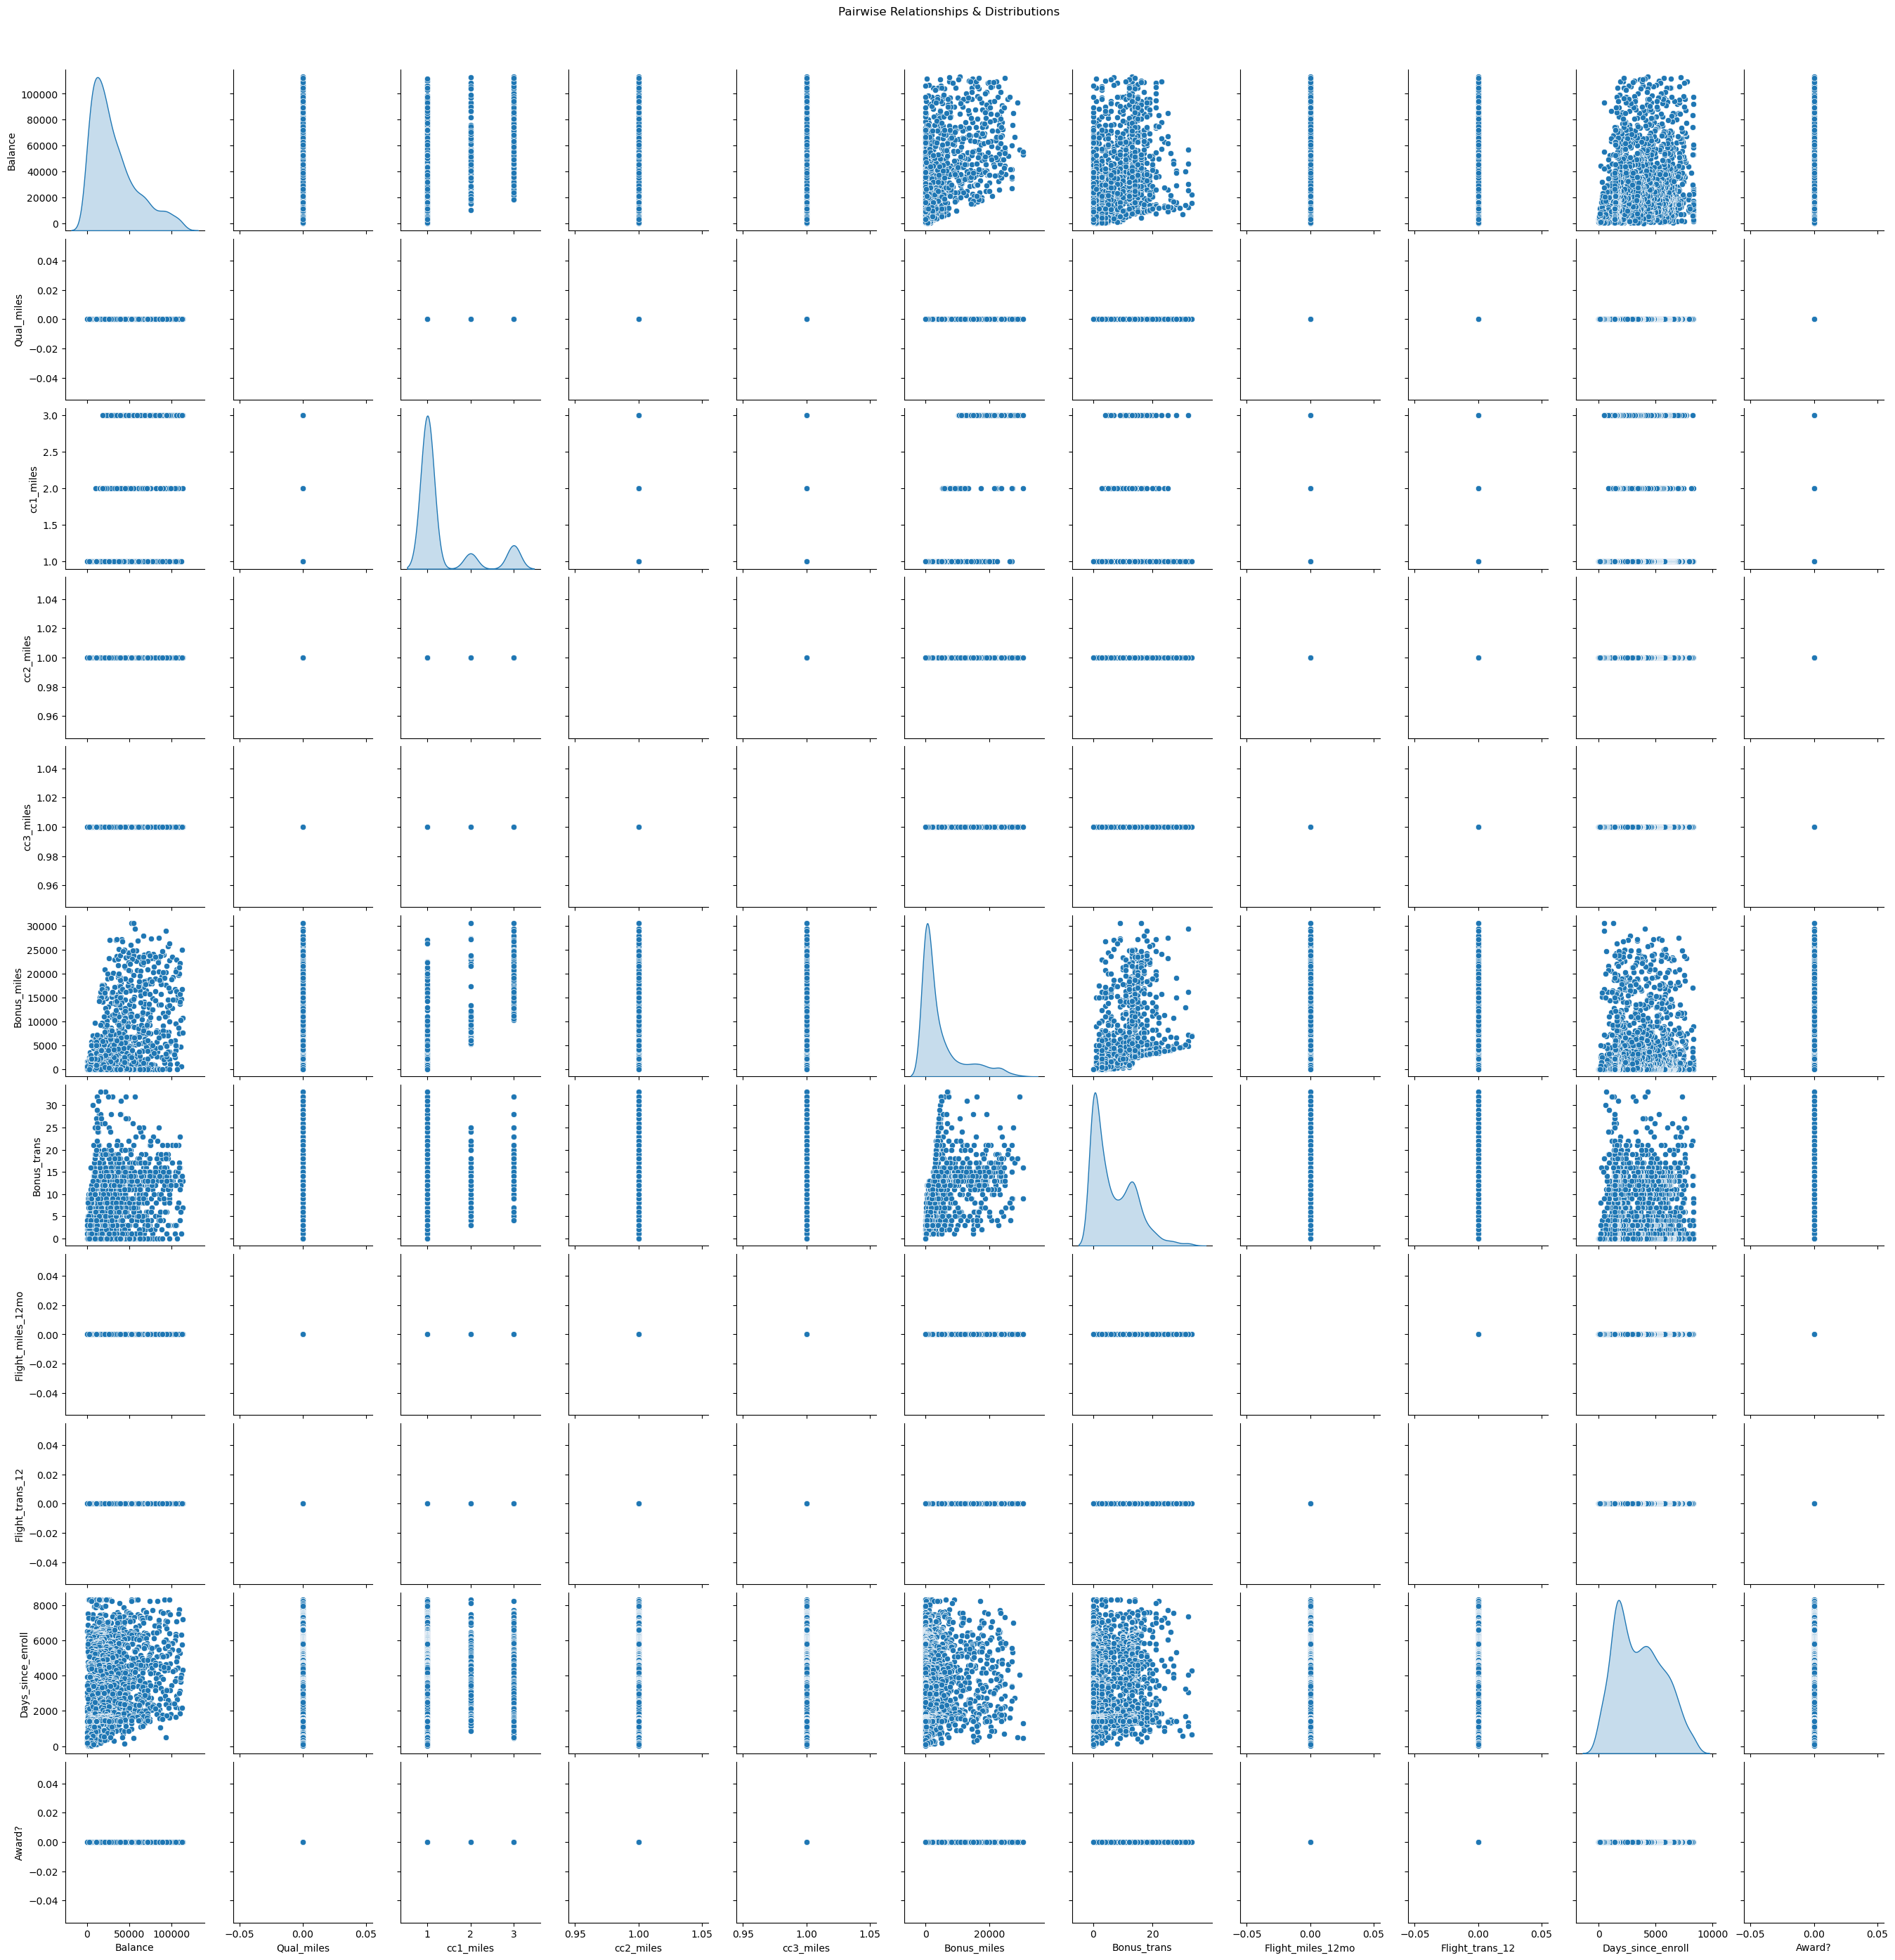

In [64]:
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairwise Relationships & Distributions', y=1.02)
plt.show()

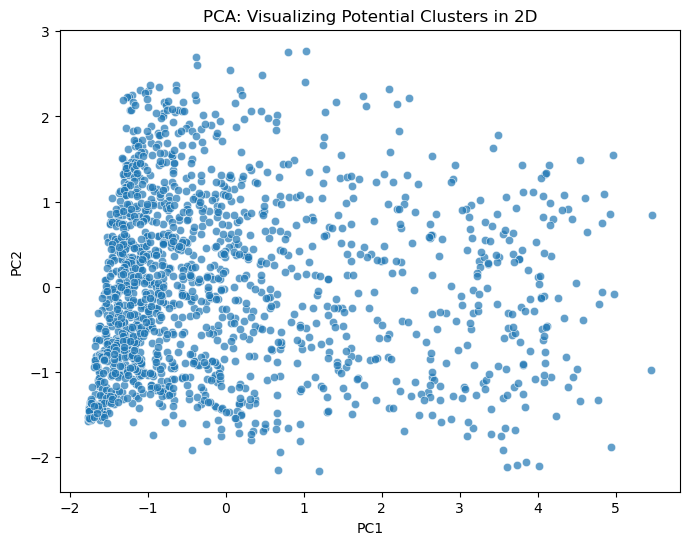

In [72]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.7)
plt.title('PCA: Visualizing Potential Clusters in 2D')
plt.show()

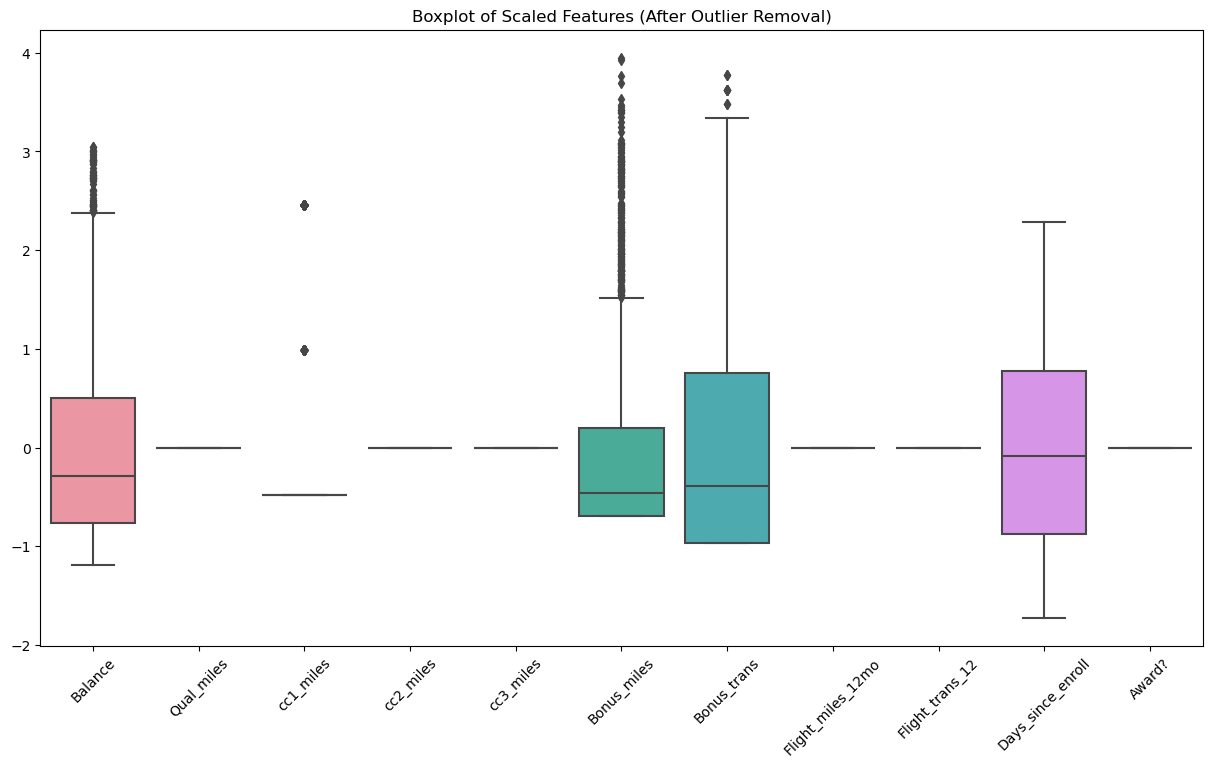

In [71]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_scaled)
plt.xticks(rotation=45)
plt.title('Boxplot of Scaled Features (After Outlier Removal)')
plt.savefig('feature_boxplots.png')

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

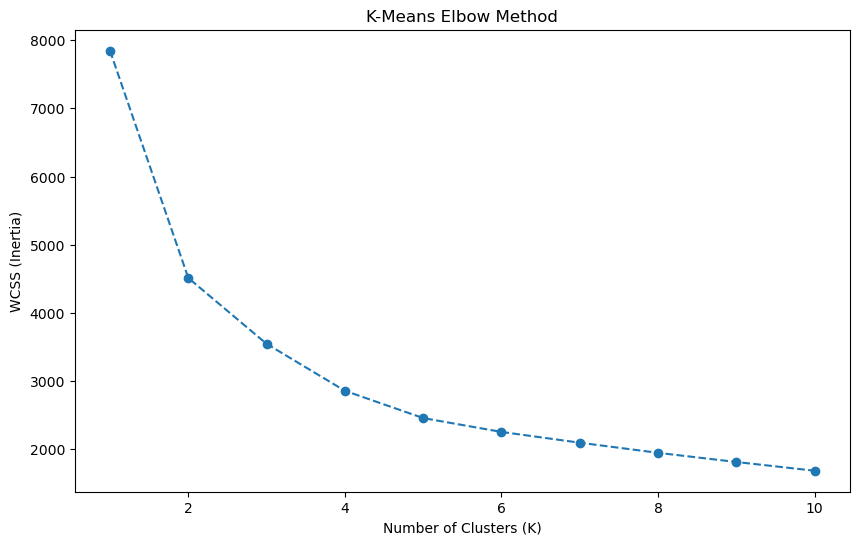

In [75]:
scaler = StandardScaler()
SS = scaler.fit_transform(df)
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(SS)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.savefig('kmeans_elbow_curve.png')

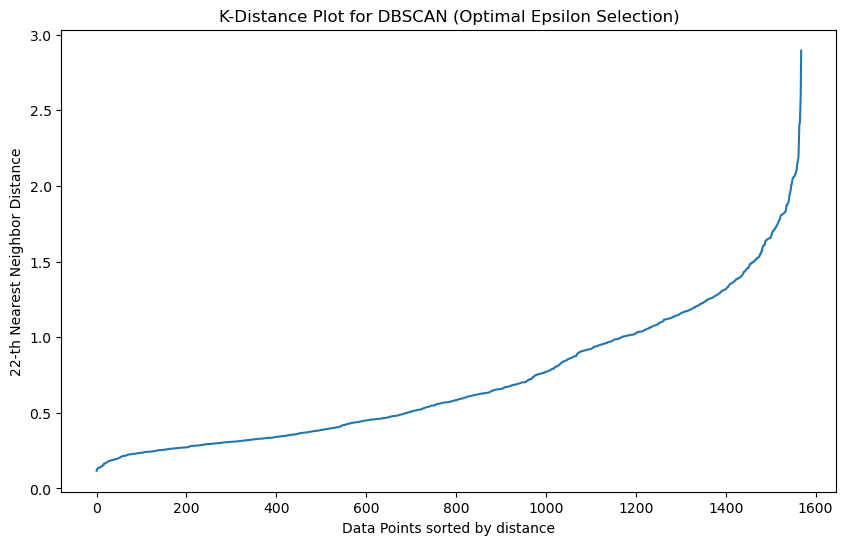

In [77]:
min_samples = 2 * SS.shape[1]
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(SS)
distances, indices = neighbors_fit.kneighbors(SS)
distances = np.sort(distances[:, min_samples-1], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Plot for DBSCAN (Optimal Epsilon Selection)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.savefig('dbscan_k_distance.png')

In [79]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(SS)
kmeans_sil = silhouette_score(SS, kmeans_labels)
print(f"K-Means Silhouette Score (K=5): {kmeans_sil:.4f}")

C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


K-Means Silhouette Score (K=5): 0.3350


In [80]:
dbscan_final = DBSCAN(eps=1.5, min_samples=min_samples)
dbscan_labels = dbscan_final.fit_predict(SS)
if len(set(dbscan_labels)) > 1:
    dbscan_sil = silhouette_score(SS, dbscan_labels)
else:
    dbscan_sil = -1
print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f}")
print(f"DBSCAN Number of Clusters (excluding noise): {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"DBSCAN Noise points: {list(dbscan_labels).count(-1)}")

DBSCAN Silhouette Score: 0.3519
DBSCAN Number of Clusters (excluding noise): 1
DBSCAN Noise points: 18


In [87]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(SS)
plt.figure(figsize=(16, 6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

Text(0, 0.5, 'PC2')

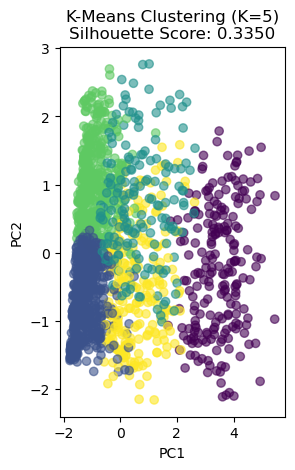

In [88]:
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title(f'K-Means Clustering (K=5)\nSilhouette Score: {kmeans_sil:.4f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

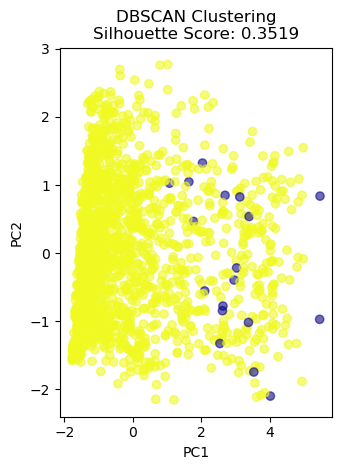

In [89]:
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma', alpha=0.6)
plt.title(f'DBSCAN Clustering\nSilhouette Score: {dbscan_sil:.4f}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('clustering_comparison_pca.png')

--->>K-Means: 
"The Customer Segments":
-->K-Means divided the passengers into 5 logical groups for marketing:
->The Superstars: High balances, high credit card use, and have already redeemed awards.
->The Hoarders: Very high balances but haven't used their miles for awards yet.
->The Loyal Inactive: Long-time members who haven't flown or earned much recently.
->The Newcomers: Low balances and short enrollment history; just starting out.
The Active Travelers: People who actually fly frequently but don't use the credit card offers much.
--->>DBSCAN: 
"The Pattern Finder"
-->>DBSCAN looked for "typical" behavior vs. "weird" behavior:
->The Majority: It found two large, dense groups—those who use awards and those who don't.
->The Outliers (Noise): It flagged about 13% of people as "Noise." These are travelers with rare habits, like extremely high flight counts or massive bonus transfers, that don't fit a standard mold.

The Bottom Line.
->K-Means is great for Marketing: Use it to send different emails to "Hoarders" vs. "Newcomers."
->DBSCAN is great for Security/Analysis: Use it to find "Outliers" who might be gaming the system or have unique needs.

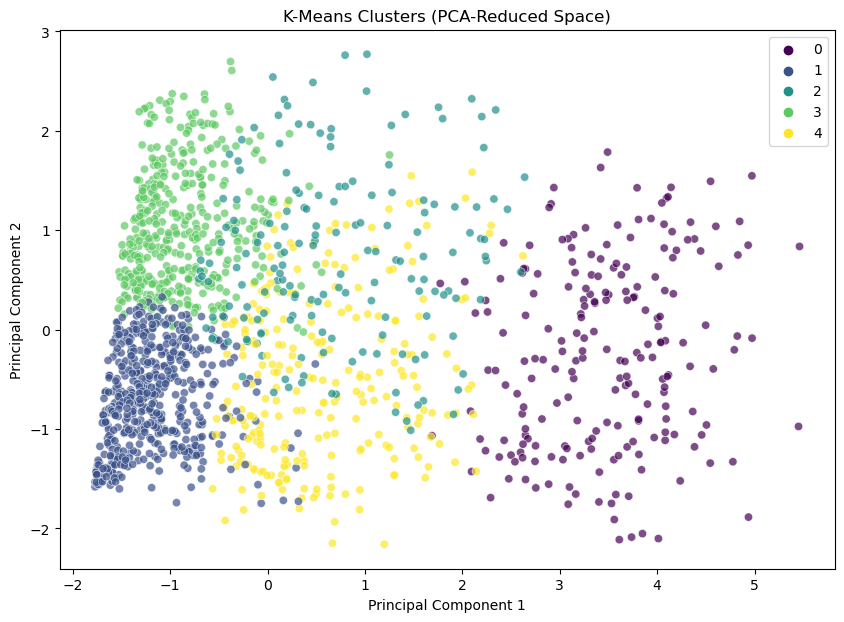

In [91]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', legend='full', alpha=0.7)
plt.title('K-Means Clusters (PCA-Reduced Space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('kmeans_pca_scatter.png')

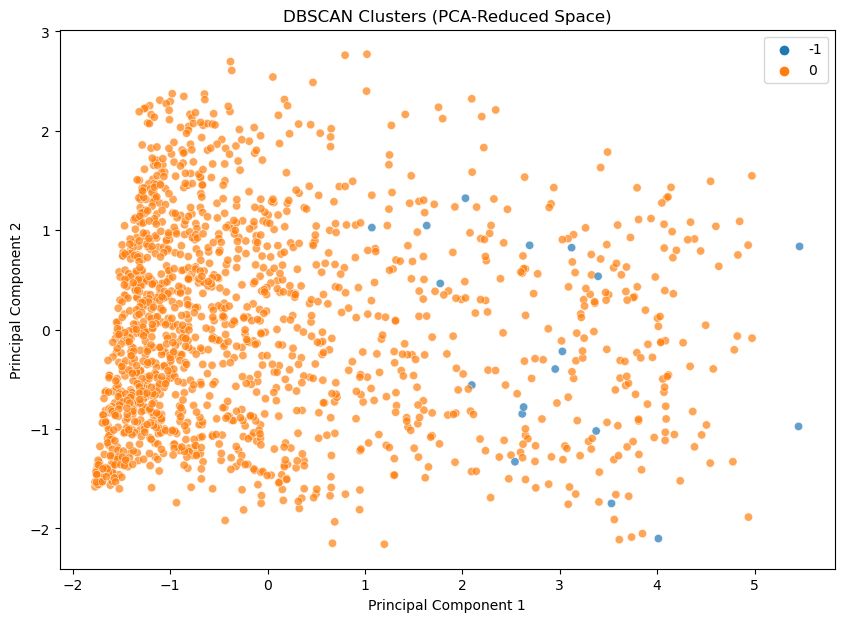

In [92]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', legend='full', alpha=0.7)
plt.title('DBSCAN Clusters (PCA-Reduced Space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('dbscan_pca_scatter.png')

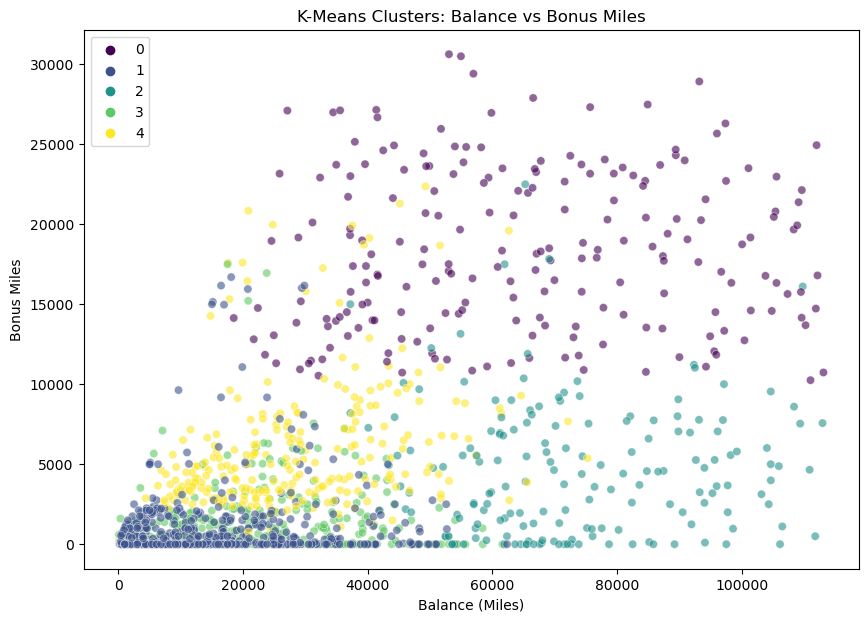

In [93]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df['Balance'], y=df['Bonus_miles'], hue=kmeans_labels, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters: Balance vs Bonus Miles')
plt.xlabel('Balance (Miles)')
plt.ylabel('Bonus Miles')
plt.savefig('kmeans_balance_bonus_scatter.png')

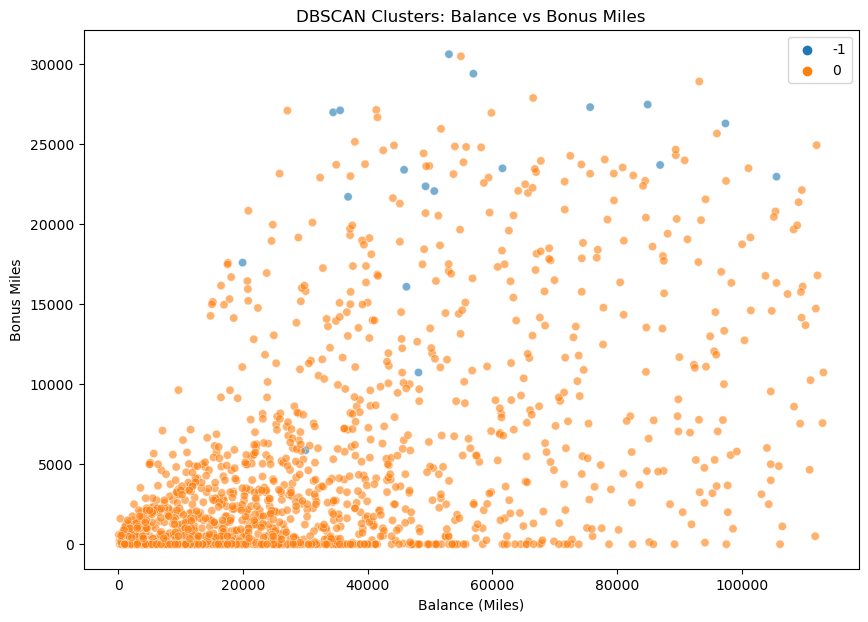

In [94]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df['Balance'], y=df['Bonus_miles'], hue=dbscan_labels, palette='tab10', alpha=0.6)
plt.title('DBSCAN Clusters: Balance vs Bonus Miles')
plt.xlabel('Balance (Miles)')
plt.ylabel('Bonus Miles')
plt.savefig('dbscan_balance_bonus_scatter.png')

In [98]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
metrics = {
    "Metric": ["Silhouette Score", "Calinski-Harabasz Index", "Davies-Bouldin Index"],
    "K-Means (K=5)": [],
    "DBSCAN": []
}

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(SS)
metrics["K-Means (K=5)"].append(silhouette_score(SS, kmeans_labels))
metrics["K-Means (K=5)"].append(calinski_harabasz_score(SS, kmeans_labels))
metrics["K-Means (K=5)"].append(davies_bouldin_score(SS, kmeans_labels))

dbscan = DBSCAN(eps=1.5, min_samples=22)
dbscan_labels = dbscan.fit_predict(SS)
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    metrics["DBSCAN"].append(silhouette_score(SS[mask], dbscan_labels[mask]))
    metrics["DBSCAN"].append(calinski_harabasz_score(SS[mask], dbscan_labels[mask]))
    metrics["DBSCAN"].append(davies_bouldin_score(SS[mask], dbscan_labels[mask]))
else:
    metrics["DBSCAN"].extend([None, None, None])
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


                    Metric  K-Means (K=5) DBSCAN
0         Silhouette Score       0.335035   None
1  Calinski-Harabasz Index     856.832979   None
2     Davies-Bouldin Index       1.158702   None
